In [14]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import pandas as pd
import uproot

In [15]:
def set_chain(df,i):
    return ((df['Chain']==i)
            & (df['Phase']==1)
            )

def set_run(df):
    return ((df['Phase']==1))

# Read the chains

BAT is set of C++ libraries implementing the Metropolis-Hastings MCMC algorithm, required for the sampling of the parameter space of the fit.

It's main output are MCMC chains and here there are some lines of code to a starting handling of such chains.

# association

In [150]:
output_filename = './output_association/association_2_mcmc.root'
mcmc = uproot.open(output_filename)
variables = ['L','x','y']
default = ['Chain','Iteration','Phase']
df = mcmc[mcmc.keys()[1]].arrays(default + variables,library='pd')

## Plot the chains

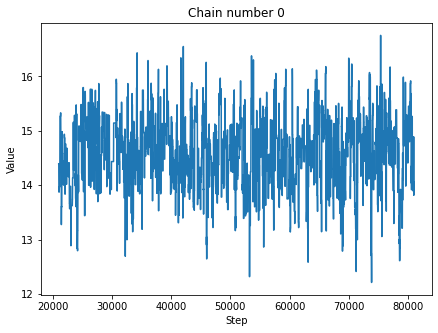

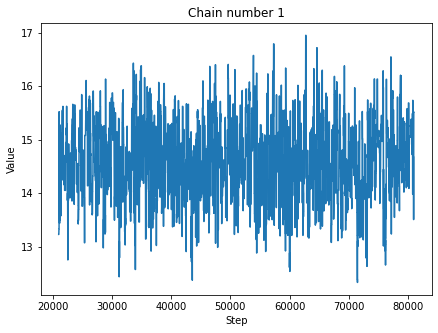

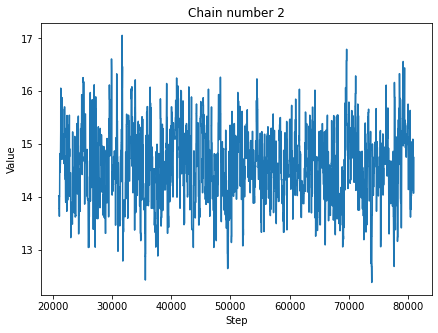

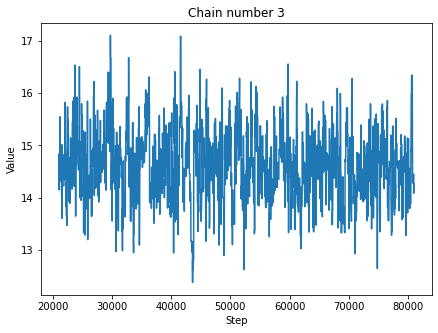

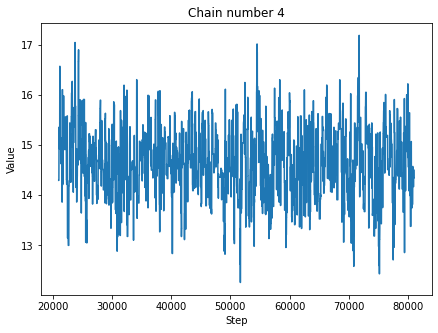

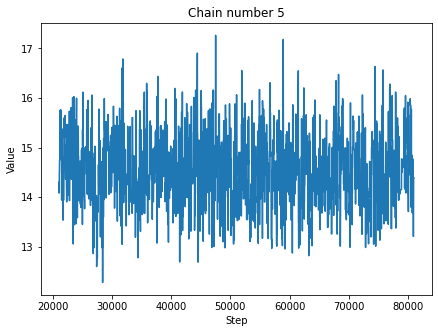

In [51]:
variable = 'x'
for ch in df['Chain'].unique():
    plt.figure(figsize=(7,5))
    plt.plot(df[set_chain(df,ch)][variable])
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.title('Chain number %d'%ch)
    plt.show()

## Posteriors and best fit values

A corner plot is an easy way to plot the probability distribution of the fitted variables and their mutual correlation. Frequentist fits usually returns you just a number, here you have direct access to the entire posterior distribution

In [151]:
for v in range(len(variables)):
    if (v==0):
        samples = df[set_run(df)][variables[v]]
    else:
        samples = np.vstack([samples,df[set_run(df)][variables[v]]])

samples = np.array(np.transpose(np.vstack(samples)))


In [111]:
import uncertainties as unc


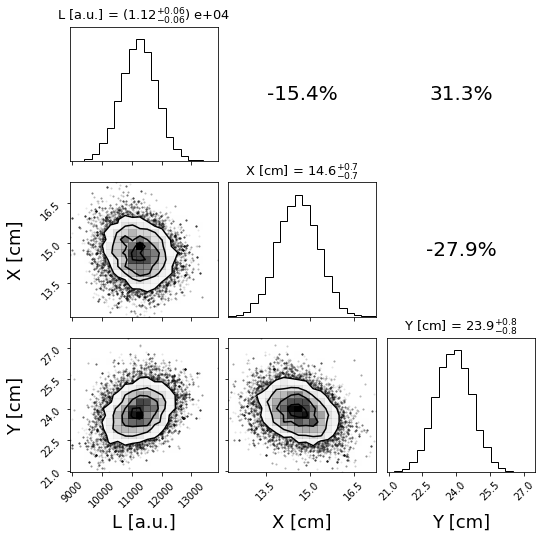

In [152]:
labels = [r'L [a.u.]', 'X [cm]', 'Y [cm]']

# figure = corner.corner(samples,
#                        labels=variables,
#                        show_titles=True,quantiles=[0.16, 0.5, 0.84],
#                        title_kwargs={"fontsize": 12},label_kwargs={"fontsize": 12},
#                        title_fmt=".2g")

figure = corner.corner(samples,
                       labels=labels,
                       label_kwargs={"fontsize": 18},
                       )

plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
# plt.suptitle("Corner Plot", fontsize=16, y=1.02)

quantiles = [16, 50, 84]
axes = np.array(figure.axes).reshape(len(variables), len(variables))

for i, label in enumerate(labels):
    vals = np.percentile(samples[:, i], quantiles)
    q_16, q_50, q_84 = vals
    median = q_50
    err_minus = q_50 - q_16
    err_plus = q_84 - q_50
    
    if 'L' in label:
        title = f"{label} = $({median/10000:.2f}^{{+{err_plus/10000:.2f}}}_{{-{err_minus/10000:.2f}}})$ e+04"
    else:
        title = f"{label} = ${median:.1f}^{{+{err_plus:.1f}}}_{{-{err_minus:.1f}}}$"
        
    # Imposta il titolo
    ax = axes[i, i]
    ax.set_title(title, fontsize=13)




corr = np.corrcoef(np.transpose(samples))

ndim = len(variables)
axes = np.array(figure.axes).reshape((ndim, ndim))

for i in range(ndim-1):
    for j in range(ndim):
        if (j>i):
            ax = axes[i, j]
            ax.text(0.5, 0.5,
                    "{0:.1f}%".format(corr[i, j]*100),
                    verticalalignment='center', horizontalalignment='center', fontsize = 20)


plt.tight_layout(pad=1.01, w_pad=0.1, h_pad=0.1)

plt.savefig('./april25/association_corner_plot.pdf',format='pdf', dpi=400)
plt.show()

In [128]:
print(f'{median:.2e}', err_minus)

2.39e+01 0.807275745774195


If you need the best values of the fit, you just take the means of the distribution. As uncertainty of such values, the standard deviation

In [8]:
print('=== Best values of the fit===')
for var in variables:
    print('%s: (%.2e +- %.2e)'%(var,np.mean( df[set_run(df)][var]),np.std( df[set_run(df)][var])))

=== Best values of the fit===
L: (7.71e+03 +- 4.99e+02)
x: (2.28e+01 +- 8.05e-01)
y: (3.96e+00 +- 1.23e+00)


# PMTcalibration

In [16]:
output_filename = './output_PMTcalibration/PMTcalibration_out.txt_mcmc.root'
# output_filename = './output_PMTcalibration/PMTcalibration_cal_test_v5.txt_mcmc.root'
mcmc = uproot.open(output_filename)
variables = ['c1','c2','c3','c4']
default = ['Chain','Iteration','Phase']
df = mcmc[mcmc.keys()[1]].arrays(default + variables,library='pd')
df

,Chain,Iteration,Phase,c1,c2,c3,c4
0,0,1,-1,9.174643,3.161442,2.205843,9.520605
1,1,1,-1,2.466090,8.344477,8.044290,3.056364
2,2,1,-1,7.752449,2.175293,9.317027,7.789592
3,3,1,-1,8.416209,3.046397,9.154226,9.876872
4,4,1,-1,4.641597,3.407283,0.760652,0.690817
...,...,...,...,...,...,...,...
1283995,7,100000,1,3.211721,3.502585,4.509404,4.105366
1283996,8,100000,1,3.190947,3.543033,4.503870,4.083398
1283997,9,100000,1,3.211896,3.599938,4.551415,4.099099
1283998,10,100000,1,3.189986,3.476958,4.516748,4.097613


## Plot the chains

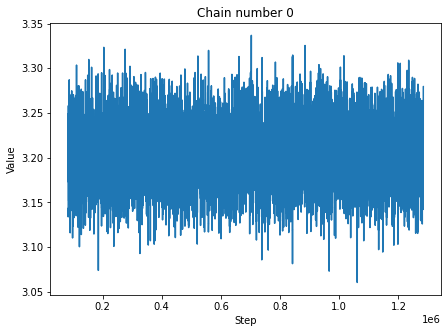

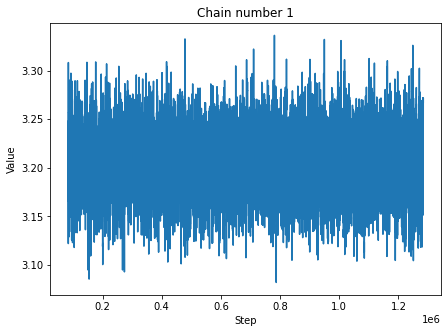

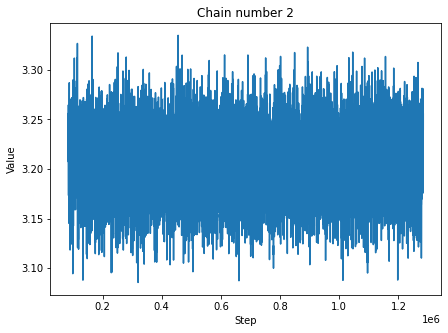

In [17]:
variable = 'c1'
for ch in df['Chain'].unique()[:3]:
    plt.figure(figsize=(7,5))
    plt.plot(df[set_chain(df,ch)][variable])
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.title('Chain number %d'%ch)
    plt.show()

In [18]:
print('=== Best values of the fit===')
for var in variables:
    print('%s: (%.3e +- %.3e)'%(var,np.mean( df[set_run(df)][var]),np.std( df[set_run(df)][var])))

=== Best values of the fit===
c1: (3.205e+00 +- 3.223e-02)
c2: (3.545e+00 +- 3.411e-02)
c3: (4.512e+00 +- 4.370e-02)
c4: (4.138e+00 +- 4.194e-02)


In [19]:
norm = 3.205

In [20]:
df['c1'] = df['c1']/norm
df['c2'] = df['c2']/norm
df['c3'] = df['c3']/norm
df['c4'] = df['c4']/norm


In [21]:
df

,Chain,Iteration,Phase,c1,c2,c3,c4
0,0,1,-1,2.862603,0.986409,0.688251,2.970548
1,1,1,-1,0.769451,2.603581,2.509919,0.953624
2,2,1,-1,2.418861,0.678719,2.907029,2.430450
3,3,1,-1,2.625962,0.950514,2.856233,3.081707
4,4,1,-1,1.448236,1.063115,0.237333,0.215543
...,...,...,...,...,...,...,...
1283995,7,100000,1,1.002097,1.092850,1.406990,1.280925
1283996,8,100000,1,0.995615,1.105471,1.405264,1.274071
1283997,9,100000,1,1.002152,1.123225,1.420098,1.278970
1283998,10,100000,1,0.995315,1.084854,1.409282,1.278506


## Posteriors and best fit values

A corner plot is an easy way to plot the probability distribution of the fitted variables and their mutual correlation. Frequentist fits usually returns you just a number, here you have direct access to the entire posterior distribution

In [22]:
for v in range(len(variables)):
    if (v==0):
        samples = df[set_run(df)][variables[v]]
    else:
        samples = np.vstack([samples,df[set_run(df)][variables[v]]])

samples = np.array(np.transpose(np.vstack(samples)))


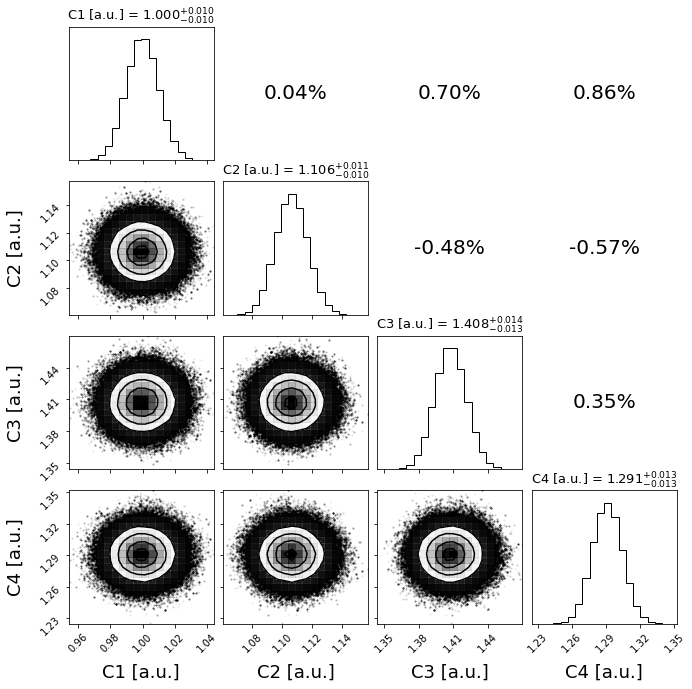

In [25]:
labels = ['C1 [a.u.]', 'C2 [a.u.]', 'C3 [a.u.]', 'C4 [a.u.]']

figure = corner.corner(samples,
                       labels=labels,
#                        show_titles=True,quantiles=[0.16, 0.5, 0.84],
#                        title_kwargs={"fontsize": 12},
                       label_kwargs={"fontsize": 18})

# figure = corner.corner(samples,
#                        labels=labels,
#                        show_titles=True,quantiles=[0.16, 0.5, 0.84],
#                        title_kwargs={"fontsize": 12},label_kwargs={"fontsize": 18})


quantiles = [16, 50, 84]
axes = np.array(figure.axes).reshape(len(variables), len(variables))

for i, label in enumerate(labels):
    vals = np.percentile(samples[:, i], quantiles)
    q_16, q_50, q_84 = vals
    median = q_50
    
    err_minus = q_50 - q_16
    err_plus = q_84 - q_50
    
    title = f"{label} = ${median:.3f}^{{+{err_plus:.3f}}}_{{-{err_minus:.3f}}}$"
        
    # Imposta il titolo
    ax = axes[i, i]
    ax.set_title(title, fontsize=13)




corr = np.corrcoef(np.transpose(samples))

ndim = len(variables)
axes = np.array(figure.axes).reshape((ndim, ndim))
for i in range(ndim-1):
    for j in range(ndim):
        if (j>i):
            ax = axes[i, j]
            ax.text(0.5, 0.5,
                    "{0:.2f}%".format(corr[i, j]*100),
                    verticalalignment='center', horizontalalignment='center', fontsize = 20)
            
plt.tight_layout(pad=1.01, w_pad=0.1, h_pad=0.1)

plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.savefig('./august25/calibration_corner_plot.pdf',format='pdf', dpi=400)
plt.show()

If you need the best values of the fit, you just take the means of the distribution. As uncertainty of such values, the standard deviation

In [24]:
print('=== Best values of the fit===')
for var in variables:
    print('%s: (%.3e +- %.3e)'%(var,np.mean( df[set_run(df)][var]),np.std( df[set_run(df)][var])))

=== Best values of the fit===
c1: (9.999e-01 +- 1.006e-02)
c2: (1.106e+00 +- 1.064e-02)
c3: (1.408e+00 +- 1.363e-02)
c4: (1.291e+00 +- 1.308e-02)
